# Module 6B — Portfolio Optimisation & Modern Portfolio Theory

In Notebook 6A we built a single 2-stock portfolio by hand — picked weights, computed the portfolio return series, and read the standard deviation off that series. That gave us the basic intuition: *blending stocks reduces risk*.

Here in 6B we go further:

1. **What's the best possible risk-return trade-off?** The **efficient frontier** traces the minimum possible risk for every target return.
2. **Where do I sit on the frontier?** The **tangency portfolio** (max Sharpe) is the natural answer under Modern Portfolio Theory.
3. **What if we have constraints?** No single stock over 40%; every stock at least 10%; etc. We solve these with `scipy.optimize`.

We work with three monthly-return stocks — the same ones from Notebook 2A:

- **RELIANCE** — low vol
- **TECHM** — medium vol
- **POONAWALLA** — high vol

Once we want to evaluate *many* candidate portfolios at once (sweeping weights, sampling 5,000 random portfolios, running an optimiser), reading std off a fresh return series for each one is wasteful. We switch to the matrix form $\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w}$ — same answer, computed from the covariance matrix in one step.


## 0. Imports and setup

We need `scipy.optimize.minimize` for constrained optimisation (it implements SLSQP — Sequential Least-Squares Programming — which handles equality constraints and bounds natively).

**Risk-free rate** — 6.5% per year, converted to a monthly rate by compounding (consistent with Notebooks 2A and 4).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)
np.random.seed(42)

RF_ANNUAL  = 0.065
RF_MONTHLY = (1 + RF_ANNUAL) ** (1/12) - 1
rf_pct     = RF_MONTHLY * 100    # in percent — same units as our returns

print(f'Annual risk-free rate:  {RF_ANNUAL:.4f}')
print(f'Monthly risk-free rate: {RF_MONTHLY:.6f}  ({rf_pct:.4f}% per month)')


Annual risk-free rate:  0.0650
Monthly risk-free rate: 0.005262  (0.5262% per month)


## 1. Load all stocks and compute the inputs we need everywhere

Every portfolio calculation that follows is driven by exactly two summary statistics:

- the **mean vector** $\boldsymbol{\mu}$ — average monthly return per stock,
- the **covariance matrix** $\Sigma$ — pairwise covariances of monthly returns.

To keep the code clean, we pack the loading into a small helper. Pass it a `{label: csv_path}` mapping; it reads the Close column of each file, computes monthly simple returns in percent, aligns the dates, and returns a single DataFrame.


In [3]:
def load_returns(file_map):
    """Load monthly OHLCV CSVs and return aligned monthly simple returns (in percent).

    Parameters
    ----------
    file_map : dict[str, str]
        Mapping of column label (ticker) to CSV path.

    Returns
    -------
    pd.DataFrame
        One column per ticker, indexed by month-end date, NA rows dropped.
    """
    series = {}
    for label, path in file_map.items():
        raw = pd.read_csv(path, index_col='Date', parse_dates=True)
        series[label] = raw['Close'].pct_change() * 100
    return pd.DataFrame(series).dropna()


returns = load_returns({
    'RELIANCE':   'datasets/monthly/RELIANCE_NS.csv',
    'TECHM':      'datasets/monthly/TECHM_NS.csv',
    'POONAWALLA': 'datasets/monthly/POONAWALLA_NS.csv',
})

# Summary statistics used by every section below
tickers = list(returns.columns)
mu_vec  = returns.mean().values             # shape (3,)
cov_mat = returns.cov().values              # shape (3, 3), pandas uses ddof=1
sd_vec  = returns.std().values              # shape (3,)

print(f'Aligned monthly returns: n = {len(returns)}')
print(f'Range: {returns.index.min().date()} to {returns.index.max().date()}')
print()
print('Mean monthly return (%):')
for t, m in zip(tickers, mu_vec):
    print(f'  {t:12s}  {m:+.4f}%')
print()
print('Monthly volatility / std (%):')
for t, s in zip(tickers, sd_vec):
    print(f'  {t:12s}  {s:.4f}%')
print()
print('Correlation matrix:')
print(returns.corr().round(3))


Aligned monthly returns: n = 59
Range: 2021-06-01 to 2026-04-01

Mean monthly return (%):
  RELIANCE      +0.6998%
  TECHM         +1.2202%
  POONAWALLA    +2.5180%

Monthly volatility / std (%):
  RELIANCE      5.7886%
  TECHM         8.4698%
  POONAWALLA    10.9131%

Correlation matrix:
            RELIANCE  TECHM  POONAWALLA
RELIANCE       1.000  0.185       0.352
TECHM          0.185  1.000       0.042
POONAWALLA     0.352  0.042       1.000


## 2. Two-stock frontier — sweep the weights

Now sweep the RELIANCE weight from 0 to 1 and trace the portfolio's (vol, return) point for each.


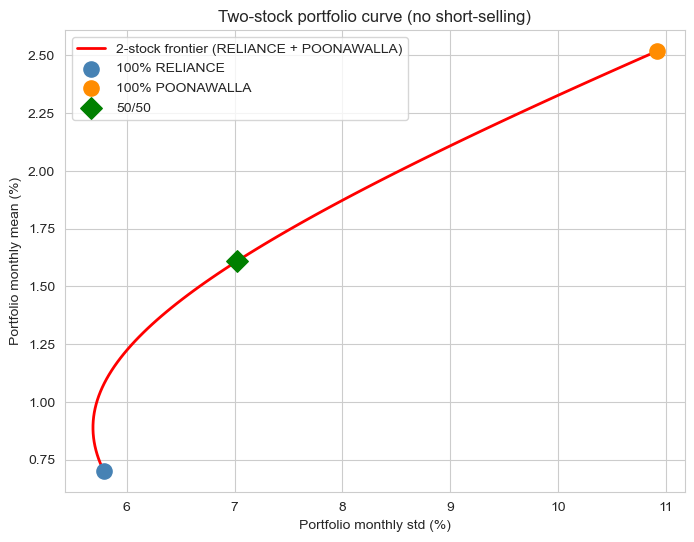

In [4]:
# Compute the two-stock summary stats inline so this section
# stands on its own (without depending on a 50/50 worked example earlier).
two = ['RELIANCE', 'POONAWALLA']
sub_mu  = returns[two].mean().values
sub_cov = returns[two].cov().values

mean_rel,  mean_poon  = sub_mu
sd_rel,    sd_poon    = np.sqrt(np.diag(sub_cov))

# 50/50 anchor — reference point on the curve
w_eq        = np.array([0.5, 0.5])
mean_eq     = w_eq @ sub_mu
sd_eq       = np.sqrt(w_eq @ sub_cov @ w_eq)

# Sweep the RELIANCE weight from 0 to 1 and trace (vol, return)
w_grid   = np.linspace(0, 1, 101)
ret_grid = np.zeros_like(w_grid)
vol_grid = np.zeros_like(w_grid)

for i, w1 in enumerate(w_grid):
    w_two = np.array([w1, 1 - w1])
    ret_grid[i] = w_two @ sub_mu
    vol_grid[i] = np.sqrt(w_two @ sub_cov @ w_two)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(vol_grid, ret_grid, 'r-', linewidth=2, label='2-stock frontier (RELIANCE + POONAWALLA)')
ax.scatter(sd_rel,   mean_rel,   s=120, color='steelblue',  zorder=5, label='100% RELIANCE')
ax.scatter(sd_poon,  mean_poon,  s=120, color='darkorange', zorder=5, label='100% POONAWALLA')
ax.scatter(sd_eq,    mean_eq,    s=120, color='green', marker='D', zorder=5, label='50/50')
ax.set_xlabel('Portfolio monthly std (%)')
ax.set_ylabel('Portfolio monthly mean (%)')
ax.set_title('Two-stock portfolio curve (no short-selling)')
ax.legend()
plt.show()


**What the curve shows.** The line is not straight — it bulges to the left. That *leftward bulge* is the diversification benefit: for *any* target return achievable by mixing the two stocks, the portfolio's volatility is **less than what a linear blend of the volatilities would be**.

The leftmost point of this curve is the **minimum-variance portfolio** — the mix that gives the smallest possible std given these two inputs.


## 3. Three-stock — Monte Carlo "cloud" of portfolios

With three stocks, we have a two-dimensional space of weights (any two determine the third, because they sum to 1). The **feasible set of portfolios** in (vol, return) space is a *region*, not a curve. We can see it by plotting many random long-only portfolios.


In [5]:
n_sim = 5000

# Generate long-only weights that sum to 1.
# Dirichlet(1,1,1) is uniform on the 3-simplex.
w_random = np.random.dirichlet(np.ones(3), size=n_sim)

sim_ret = np.zeros(n_sim)
sim_vol = np.zeros(n_sim)

for i in range(n_sim):
    w_i = w_random[i]
    sim_ret[i] = w_i @ mu_vec
    sim_vol[i] = np.sqrt(w_i @ cov_mat @ w_i)

# Monthly Sharpe — risk-free rate is already in % per month (rf_pct)
sim_sharpe_monthly = (sim_ret - rf_pct) / sim_vol

print(f'Simulated {n_sim} random long-only portfolios.')
print(f'Portfolio monthly-return range: {sim_ret.min():+.2f}% to {sim_ret.max():+.2f}%')
print(f'Portfolio monthly-vol    range: {sim_vol.min():.2f}% to {sim_vol.max():.2f}%')


Simulated 5000 random long-only portfolios.
Portfolio monthly-return range: +0.71% to +2.50%
Portfolio monthly-vol    range: 5.08% to 10.80%


### 3.1  Plot the cloud, coloured by Sharpe ratio

Each dot is one random long-only portfolio. The cloud's upper-left boundary is the **efficient frontier**: for any given risk level, the highest return you can get.


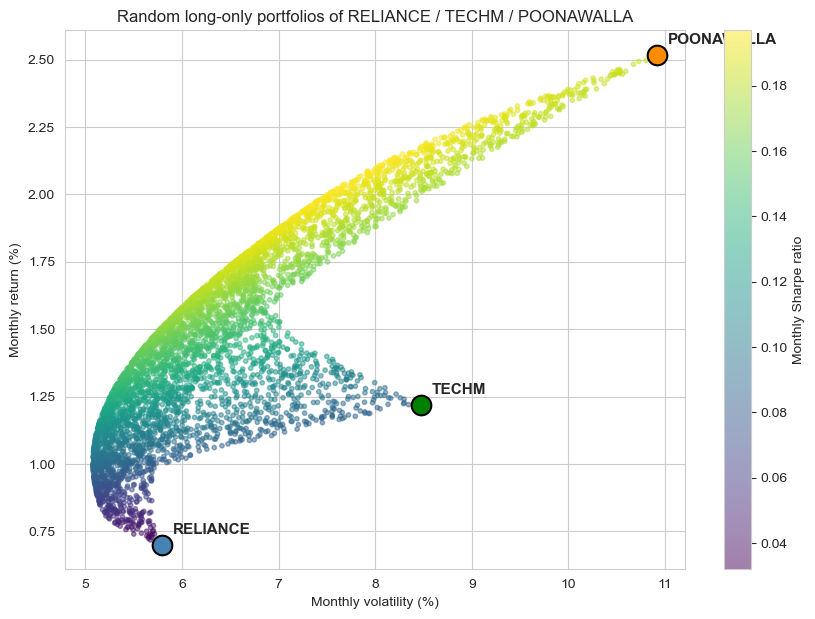

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(sim_vol, sim_ret, c=sim_sharpe_monthly,
                cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, label='Monthly Sharpe ratio')

# Mark the three single-stock points
for t, v, r, color in zip(tickers, sd_vec, mu_vec,
                           ['steelblue', 'green', 'darkorange']):
    ax.scatter(v, r, s=200, color=color, edgecolor='black', linewidth=1.5, zorder=5)
    ax.annotate(t, (v, r), xytext=(8, 8), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax.set_xlabel('Monthly volatility (%)')
ax.set_ylabel('Monthly return (%)')
ax.set_title('Random long-only portfolios of RELIANCE / TECHM / POONAWALLA')
plt.show()

The three big coloured dots are the "100% one stock" portfolios. Notice that *mixtures* can land at positions that no single stock reaches — especially in the upper-left region (lower risk, higher return). That upper-left edge is what we'll trace analytically in the next section.


## 4. The Global Minimum Variance portfolio (GMV)

The **Global Minimum Variance** portfolio is the single portfolio with the smallest possible variance, regardless of return:

$$
\text{minimize}\;\; \mathbf{w}^T \Sigma \mathbf{w}
\quad\text{subject to}\quad \sum_i w_i = 1,\;\; w_i \geq 0.
$$

We use `scipy.optimize.minimize` with the **SLSQP** method, which supports:

- a nonlinear objective (the variance, which is quadratic in $w$),
- an equality constraint ($\sum w_i = 1$),
- box bounds ($0 \leq w_i \leq 1$, i.e. no short-selling).


### 4.1  Set up the optimiser and solve


In [8]:
# Starting guess: equal weights
w0 = np.ones(3) / 3

# Bounds: each weight is between 0 and 1 (long-only)
bounds_long_only = [(0.0, 1.0)] * 3

# Equality constraint: weights sum to 1
constraint_sum1 = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

gmv = minimize(
    lambda w: w @ cov_mat @ w,
    w0,
    method='SLSQP',
    bounds=bounds_long_only,
    constraints=constraint_sum1,
)

gmv_weights = gmv.x
gmv_return  = gmv_weights @ mu_vec
gmv_vol     = np.sqrt(gmv_weights @ cov_mat @ gmv_weights)
gmv_sharpe  = (gmv_return - rf_pct) / gmv_vol

print(f'GMV optimisation success: {gmv.success}')
print(f'\nGMV weights:')
for t, w_i in zip(tickers, gmv_weights):
    print(f'  {t:12s}  {w_i*100:6.2f}%')
print(f'  sum         {gmv_weights.sum()*100:6.2f}%')
print(f'\nGMV portfolio monthly return: {gmv_return:+.4f}%')
print(f'GMV portfolio monthly vol:    {gmv_vol:.4f}%')
print(f'GMV monthly Sharpe:           {gmv_sharpe:+.4f}')


GMV optimisation success: True

GMV weights:
  RELIANCE       63.69%
  TECHM          27.44%
  POONAWALLA      8.87%
  sum         100.00%

GMV portfolio monthly return: +1.0038%
GMV portfolio monthly vol:    5.0794%
GMV monthly Sharpe:           +0.0940


**Reading the weights.** The GMV portfolio is usually dominated by whichever assets have the **lowest standalone variance** or the most *negatively correlated* pairs. RELIANCE should get a heavy weight; POONAWALLA (high vol) gets little. The GMV minimises risk — it pays no attention to the expected returns.


## 5. The tangency portfolio — maximise the Sharpe ratio

The **tangency portfolio** is where a line from the risk-free point $(0, r_f)$ just touches the efficient frontier — it has the highest possible Sharpe ratio among long-only combinations.

$$
\text{maximise}\;\; \frac{\mathbf{w}^T \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^T \Sigma \mathbf{w}}}
\quad\text{subject to}\quad \sum w_i = 1,\; w_i \geq 0.
$$

`scipy.optimize.minimize` minimises, so we **minimise the negative Sharpe**.


In [10]:
tangency = minimize(
    lambda w: -(w @ mu_vec - rf_pct) / np.sqrt(w @ cov_mat @ w),
    w0,
    method='SLSQP',
    bounds=bounds_long_only,
    constraints=constraint_sum1,
)

tan_weights = tangency.x
tan_return  = tan_weights @ mu_vec
tan_vol     = np.sqrt(tan_weights @ cov_mat @ tan_weights)
tan_sharpe  = (tan_return - rf_pct) / tan_vol

print(f'Tangency optimisation success: {tangency.success}')
print(f'\nTangency weights:')
for t, w_i in zip(tickers, tan_weights):
    print(f'  {t:12s}  {w_i*100:6.2f}%')
print(f'\nTangency portfolio monthly return: {tan_return:+.4f}%')
print(f'Tangency portfolio monthly vol:    {tan_vol:.4f}%')
print(f'Tangency monthly Sharpe:           {tan_sharpe:+.4f}')


Tangency optimisation success: True

Tangency weights:
  RELIANCE        0.00%
  TECHM          34.95%
  POONAWALLA     65.05%

Tangency portfolio monthly return: +2.0644%
Tangency portfolio monthly vol:    7.8052%
Tangency monthly Sharpe:           +0.1971


The tangency portfolio is "the best long-only blend" under MPT — every investor, regardless of their risk tolerance, would hold it in some proportion mixed with the risk-free asset (this is the **Tobin two-fund separation theorem**).


## 6. Trace the efficient frontier

The efficient frontier is the set of portfolios that achieve the **minimum volatility for each target return**. Algorithm:

1. Pick a grid of target returns between `min(μ_i)` and `max(μ_i)`.
2. For each target, solve:

$$
\text{minimize}\; \mathbf{w}^T \Sigma \mathbf{w}
\;\;\text{subject to}\;\;
\mathbf{w}^T \boldsymbol{\mu} = \text{target}, \;\;
\sum w_i = 1, \;\; w_i \geq 0.
$$

3. Plot the resulting (vol, target-return) pairs.


In [11]:
target_returns = np.linspace(mu_vec.min(), mu_vec.max(), 40)

frontier_vols = []
frontier_weights = []

for target in target_returns:
    constraints_both = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        # default argument `t=target` captures the current target (avoids late-binding)
        {'type': 'eq', 'fun': lambda w, t=target: w @ mu_vec - t},
    ]
    res = minimize(
        lambda w: w @ cov_mat @ w,
        w0,
        method='SLSQP',
        bounds=bounds_long_only,
        constraints=constraints_both,
    )
    if res.success:
        frontier_vols.append(np.sqrt(res.fun))
        frontier_weights.append(res.x)
    else:
        frontier_vols.append(np.nan)
        frontier_weights.append(np.full(3, np.nan))

frontier_vols = np.array(frontier_vols)
print(f'Frontier points computed: {np.isfinite(frontier_vols).sum()} out of {len(target_returns)}')


Frontier points computed: 40 out of 40


**Trick used above** — `lambda w, t=target: ...` uses a default argument to capture the loop variable. Without this, every lambda would reference the *same* `target` (Python's late-binding rule), and they'd all end up with whatever the last value was.


## 7. The full picture — frontier, GMV, tangency, single stocks, CAL

The **Capital Allocation Line (CAL)** starts at $(0, r_f)$ on the y-axis and passes through the tangency portfolio. Its slope is the tangency portfolio's Sharpe ratio. Every point on the CAL is a blend of the tangency portfolio with the risk-free asset.


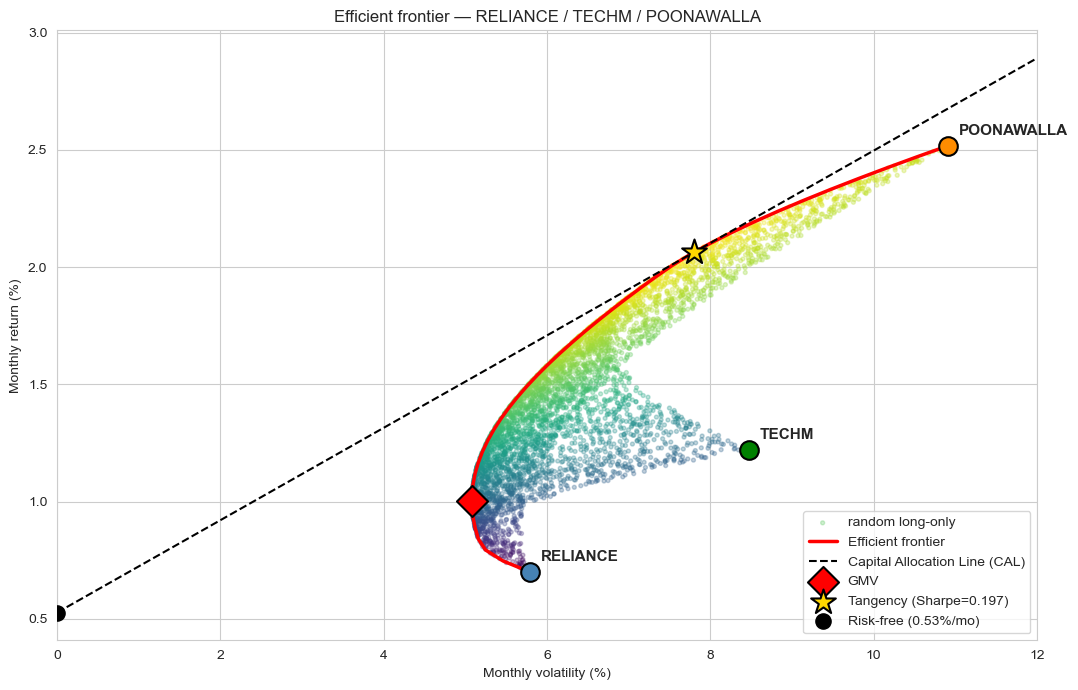

In [12]:
# Build the CAL line — from (0, rf_pct) through (tan_vol, tan_return), extended
cal_x = np.linspace(0, max(sd_vec) * 1.1, 100)
cal_slope = (tan_return - rf_pct) / tan_vol
cal_y = rf_pct + cal_slope * cal_x

fig, ax = plt.subplots(figsize=(11, 7))

# Random-portfolio cloud (monthly)
ax.scatter(sim_vol, sim_ret, c=sim_sharpe_monthly, cmap='viridis',
           alpha=0.3, s=8, label='random long-only')

# Efficient frontier
mask = np.isfinite(frontier_vols)
ax.plot(frontier_vols[mask], target_returns[mask],
        'r-', linewidth=2.5, label='Efficient frontier')

# Capital Allocation Line
ax.plot(cal_x, cal_y, 'k--', linewidth=1.5, label='Capital Allocation Line (CAL)')

# Single stocks
for t, v, r, color in zip(tickers, sd_vec, mu_vec,
                           ['steelblue', 'green', 'darkorange']):
    ax.scatter(v, r, s=180, color=color, edgecolor='black', linewidth=1.5, zorder=5)
    ax.annotate(t, (v, r), xytext=(8, 8), textcoords='offset points',
                fontsize=11, fontweight='bold')

# Special points
ax.scatter(gmv_vol, gmv_return, s=250, color='red', marker='D',
           edgecolor='black', linewidth=1.5, zorder=6, label='GMV')
ax.scatter(tan_vol, tan_return, s=350, color='gold', marker='*',
           edgecolor='black', linewidth=1.5, zorder=6,
           label=f'Tangency (Sharpe={tan_sharpe:.3f})')
ax.scatter(0, rf_pct, s=120, color='black', marker='o', zorder=6,
           label=f'Risk-free ({rf_pct:.2f}%/mo)')

ax.set_xlabel('Monthly volatility (%)')
ax.set_ylabel('Monthly return (%)')
ax.set_title('Efficient frontier — RELIANCE / TECHM / POONAWALLA')
ax.set_xlim(0, max(sd_vec) * 1.1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Reading the plot**

- **Red curve (efficient frontier)** — for every achievable return, the lowest possible long-only volatility.
- **Red diamond (GMV)** — the leftmost point; minimum risk, no view on return.
- **Gold star (tangency)** — the single best long-only Sharpe ratio.
- **Black dashed line (CAL)** — combinations of the tangency portfolio with the risk-free asset. Every point on the CAL *above* the risk-free point is better than any point below it on the frontier (for the same level of risk).
- **Individual stocks** — sit **inside** the frontier. Holding one stock alone is inefficient; we can always find a portfolio with the same return and lower risk.

**That last point is the Markowitz result** — no single stock is efficient; portfolios dominate.


## 8. Applying constraints — "no single stock over 40%"

So far we've required $0 \leq w_i \leq 1$ — long-only, but no concentration limits. Real portfolios typically have constraints:

- **Concentration caps** — no single stock over some threshold (e.g. 40%).
- **Minimum weights** — every stock must be held (e.g. at least 10%).
- **Group constraints** — sector caps (not demonstrated here but the mechanism is the same).

Each constraint is just a tighter bound or an additional equality/inequality fed into `minimize`.


### 8.1  Cap every weight at 40% — re-solve the tangency


In [13]:
bounds_cap40 = [(0.0, 0.40)] * 3

tangency_capped = minimize(
    lambda w: -(w @ mu_vec - rf_pct) / np.sqrt(w @ cov_mat @ w),
    w0,
    method='SLSQP',
    bounds=bounds_cap40,
    constraints=constraint_sum1,
)

tan_cap_w      = tangency_capped.x
tan_cap_ret    = tan_cap_w @ mu_vec
tan_cap_vol    = np.sqrt(tan_cap_w @ cov_mat @ tan_cap_w)
tan_cap_sharpe = (tan_cap_ret - rf_pct) / tan_cap_vol

print(f'Tangency with 40% cap — success: {tangency_capped.success}')
print('\nWeights:')
for t, w_i in zip(tickers, tan_cap_w):
    print(f'  {t:12s}  {w_i*100:6.2f}%')
print(f'\nMonthly Sharpe: {tan_cap_sharpe:.4f}  (unconstrained was {tan_sharpe:.4f})')


Tangency with 40% cap — success: True

Weights:
  RELIANCE       20.00%
  TECHM          40.00%
  POONAWALLA     40.00%

Monthly Sharpe: 0.1796  (unconstrained was 0.1971)


The 40% cap forces the optimiser to spread weight away from the asset it would otherwise over-weight. The constrained Sharpe is **at most** the unconstrained Sharpe — constraints can never make the optimum better.


### 8.2  Require every stock at least 10% — re-solve again


In [14]:
bounds_floor10 = [(0.10, 1.0)] * 3

tangency_floor = minimize(
    lambda w: -(w @ mu_vec - rf_pct) / np.sqrt(w @ cov_mat @ w),
    w0,
    method='SLSQP',
    bounds=bounds_floor10,
    constraints=constraint_sum1,
)

tan_floor_w      = tangency_floor.x
tan_floor_ret    = tan_floor_w @ mu_vec
tan_floor_vol    = np.sqrt(tan_floor_w @ cov_mat @ tan_floor_w)
tan_floor_sharpe = (tan_floor_ret - rf_pct) / tan_floor_vol

print(f'Tangency with 10% floor — success: {tangency_floor.success}')
print('\nWeights:')
for t, w_i in zip(tickers, tan_floor_w):
    print(f'  {t:12s}  {w_i*100:6.2f}%')
print(f'\nMonthly Sharpe: {tan_floor_sharpe:.4f}')


Tangency with 10% floor — success: True

Weights:
  RELIANCE       10.00%
  TECHM          30.37%
  POONAWALLA     59.63%

Monthly Sharpe: 0.1928


### 8.3  Combined — every weight between 10% and 50%

Real mandates almost always specify **both** a floor and a cap on each holding — a typical book might say "no single name above 50%, and every name we hold gets at least 10% so no position is too small to matter".

Implementing it is just one bounds list — `(low, high)` per weight — handed to `scipy.optimize.minimize`. Nothing else changes.


In [19]:
bounds_combined = [(0.10, 0.50)] * 3

tangency_combined = minimize(
    lambda w: -(w @ mu_vec - rf_pct) / np.sqrt(w @ cov_mat @ w),
    w0,
    method='SLSQP',
    bounds=bounds_combined,
    constraints=constraint_sum1,
)

tan_comb_w      = tangency_combined.x
tan_comb_ret    = tan_comb_w @ mu_vec
tan_comb_vol    = np.sqrt(tan_comb_w @ cov_mat @ tan_comb_w)
tan_comb_sharpe = (tan_comb_ret - rf_pct) / tan_comb_vol

print(f'Tangency with 10%-50% bounds — success: {tangency_combined.success}')
print('\nWeights:')
for t, w_i in zip(tickers, tan_comb_w):
    print(f'  {t:12s}  {w_i*100:6.2f}%')
print(f'\nMonthly Sharpe: {tan_comb_sharpe:.4f}')


Tangency with 10%-50% bounds — success: True

Weights:
  RELIANCE       10.00%
  TECHM          40.00%
  POONAWALLA     50.00%

Monthly Sharpe: 0.1901


### 8.4  Side-by-side comparison of the four tangency portfolios


In [20]:
compare = pd.DataFrame({
    'Unconstrained':    list(tan_weights)  + [tan_sharpe],
    '40% cap':          list(tan_cap_w)    + [tan_cap_sharpe],
    '10% floor':        list(tan_floor_w)  + [tan_floor_sharpe],
    '10%-50% bounds':   list(tan_comb_w)   + [tan_comb_sharpe],
}, index=tickers + ['Monthly Sharpe']).round(4)
compare


,Unconstrained,40% cap,10% floor,10%-50% bounds
RELIANCE,0.0000,0.2000,0.1000,0.1000
TECHM,0.3495,0.4000,0.3037,0.4000
POONAWALLA,0.6505,0.4000,0.5963,0.5000
Monthly Sharpe,0.1971,0.1796,0.1928,0.1901


**Key observation.** Each constraint narrows the feasible set, so the constrained Sharpe is **never higher** than the unconstrained Sharpe — by how much depends on how tight the constraint is and where the unconstrained optimum was sitting. The point isn't that constraints are bad; it's that you *pay* for them in expected risk-adjusted return, and the optimiser tells you exactly how much.


---

## 9. Summary

**Portfolio risk is not a weighted average of individual risks.** Correlations below 1 create a diversification benefit — portfolio std is strictly less than the weighted-average std. This is the "free lunch" that motivates the whole MPT framework.

**Efficient frontier** — the set of long-only portfolios with the lowest volatility for each achievable return. Every individual stock lies *inside* the frontier; no single stock is efficient on its own.

**Two special points on the frontier**

- **GMV** — minimum variance, blind to expected return.
- **Tangency** — maximum Sharpe ratio. Every MPT investor holds this, mixed with the risk-free asset, in proportions determined by their risk tolerance (Tobin separation).

**Constraints** — easily handled by `scipy.optimize.minimize`. The constrained optimum can never beat the unconstrained optimum; the gap between them tells you the cost of the constraint.

**A caveat worth emphasising.** Everything depends on the two inputs $\boldsymbol{\mu}$ and $\Sigma$ — both estimated from 59 monthly observations. Mean returns estimated from so few data points are extremely noisy (we saw this in Notebook 3 — SEs are large). Optimisers are **very sensitive** to errors in μ. Professional portfolio construction therefore uses shrinkage estimators, Black-Litterman, robust optimisation, or other techniques to dampen the sensitivity.


---

## End-of-notebook exercises

### Exercise 1 — Allow short-selling

Change `bounds_long_only` from `(0, 1)` to `(-0.5, 1.5)` on each weight and re-solve the tangency. Does the Sharpe improve? By how much? What weights does the optimiser now want?

### Exercise 2 — Different risk-free rate

Re-run the tangency for **$r_f = 3\%$** annual and **$r_f = 10\%$** annual (converted by compounding). The GMV doesn't move (it depends only on $\Sigma$), but the tangency should shift along the frontier. Explain why.

### Exercise 3 — Add a fourth stock

Load a fourth file from `./monthly/` (e.g. `COLPAL_NS.csv`), align with the existing three, re-estimate $\boldsymbol{\mu}$ and $\Sigma$ on the 4-stock universe, and re-trace the frontier. Does the frontier shift up-and-to-the-left (more diversification benefit) or stay roughly the same?

### Exercise 4 — Sector or group constraints

Suppose RELIANCE + POONAWALLA together must be at most 50%. Implement this as an *inequality* constraint:

```python
sector_cap = {'type': 'ineq', 'fun': lambda w: 0.5 - w[0] - w[2]}
```

and resolve the tangency. Note: `'ineq'` constraints must return values ≥ 0 to be feasible.

### Exercise 5 — Rolling tangency portfolio

Compute a **24-month rolling tangency portfolio**: at each month-end, use the most recent 24 months of returns to re-estimate μ and Σ, solve for the tangency, and record the weights and the Sharpe. Plot the three stocks' weights over time. Do they move smoothly or jump around? What does the jumpiness tell you about estimation noise?

### Exercise 6 — Robustness to estimation error

Perturb the mean vector by a small random shock: `mu_vec_noisy = mu_vec + np.random.normal(0, 0.5, size=3)` (i.e. add ±50 bp noise). Re-solve the tangency. Repeat 100 times. How much do the resulting weights move? This is a simple illustration of why **optimisers over-fit noise** — and why real-world portfolio construction uses shrinkage / regularisation.

### Exercise 7 — Equal-risk-contribution (risk parity)

Instead of maximising Sharpe, solve for weights where **each stock contributes equally to portfolio risk**:

$$
w_i \cdot (\Sigma \mathbf{w})_i \;\text{is the same for all } i.
$$

Hint: minimise the variance of the vector of risk contributions. How do the risk-parity weights compare to GMV and tangency?
